# Часть 1: Настройка окружения и подготовка данных

## Установка необходимых библиотек

In [18]:
#!pip install tensorflow keras scikit-learn numpy matplotlib seaborn pandas xgboost lightgbm plotly scikit-optimize

## Подготовка датасетов различной сложности

### Датасет 1: Классификация (Fashion-MNIST)

In [19]:
import tensorflow as tf
from tensorflow import keras

(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()
x_train_fashion = x_train_fashion.astype('float32') / 255.0
x_test_fashion = x_test_fashion.astype('float32') / 255.0
x_train_fashion = x_train_fashion.reshape(-1, 28*28)
x_test_fashion = x_test_fashion.reshape(-1, 28*28)

print(f'Fashion-MNIST Тренировочный размер: {x_train_fashion.shape}, {y_train_fashion.shape}')
print(f'Fashion-MNIST Тестовый размер: {x_test_fashion.shape}, {y_test_fashion.shape}')

Fashion-MNIST Тренировочный размер: (60000, 784), (60000,)
Fashion-MNIST Тестовый размер: (10000, 784), (10000,)


### Датасет 2: Регрессия (California Housing)

In [20]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

california_housing = fetch_california_housing(as_frame=True)
X_cal, y_cal = california_housing.data, california_housing.target

X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)

scaler_cal = StandardScaler()
X_train_cal_scaled = scaler_cal.fit_transform(X_train_cal)
X_test_cal_scaled = scaler_cal.transform(X_test_cal)

print(f'California Housing Тренировочный размер: {X_train_cal_scaled.shape}, {y_train_cal.shape}')
print(f'California Housing Тестовый размер: {X_test_cal_scaled.shape}, {y_test_cal.shape}')

California Housing Тренировочный размер: (16512, 8), (16512,)
California Housing Тестовый размер: (4128, 8), (4128,)


### Датасет 3: Синтетические данные с нелинейными зависимостями

In [21]:
from sklearn.datasets import make_classification
import numpy as np

X_synth, y_synth = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, n_repeated=0, n_classes=2, n_clusters_per_class=2, weights=[0.5, 0.5], flip_y=0.01, random_state=42)

X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42)

print(f'Synthetic Dataset Тренировочный размер: {X_train_synth.shape}, {y_train_synth.shape}')
print(f'Synthetic Dataset Тестовый размер: {X_test_synth.shape}, {y_test_synth.shape}')

Synthetic Dataset Тренировочный размер: (800, 20), (800,)
Synthetic Dataset Тестовый размер: (200, 20), (200,)


# Часть 2: Базовые методы ансамблирования

## Задача 2.1: Бэггинг нейронных сетей

Используем Датасет 1 (Fashion-MNIST). Реализуем бэггинг ансамбль из 5 многослойных нейронных сетей с различными архитектурами, функциями активации и инициализациями весов.

In [22]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def create_mlp_model(input_dim, output_dim, architecture_type='shallow', activation='relu', initializer='glorot_uniform'):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))
    if architecture_type == 'shallow':
        model.add(keras.layers.Dense(64, activation=activation, kernel_initializer=initializer))
        model.add(keras.layers.Dense(output_dim, activation='softmax'))
    elif architecture_type == 'deep':
        model.add(keras.layers.Dense(128, activation=activation, kernel_initializer=initializer))
        model.add(keras.layers.Dense(64, activation=activation, kernel_initializer=initializer))
        model.add(keras.layers.Dense(output_dim, activation='softmax'))
    elif architecture_type == 'wide':
        model.add(keras.layers.Dense(256, activation=activation, kernel_initializer=initializer))
        model.add(keras.layers.Dense(output_dim, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Параметры для разнообразия
architectures = ['shallow', 'deep', 'wide']
activations = ['relu', 'tanh']
initializers = ['glorot_uniform', 'he_normal']

ensemble_models = []
history_list = []

input_dim = x_train_fashion.shape[1]
output_dim = len(np.unique(y_train_fashion))

for i in range(5):
    arch = architectures[i % len(architectures)]
    act = activations[i % len(activations)]
    init = initializers[i % len(initializers)]
    print(f'Model {i+1}: Architecture={arch}, Activation={act}, Initializer={init}')
    model = create_mlp_model(input_dim, output_dim, arch, act, init)
    history = model.fit(x_train_fashion, y_train_fashion, epochs=5, verbose=0, validation_data=(x_test_fashion, y_test_fashion))
    ensemble_models.append(model)
    history_list.append(history)

# Делаем предсказания для разных моделей
individual_predictions = np.array([model.predict(x_test_fashion) for model in ensemble_models])

# Агрегируем данные
ensemble_predictions_classes = np.argmax(np.mean(individual_predictions, axis=0), axis=1)
ensemble_accuracy = accuracy_score(y_test_fashion, ensemble_predictions_classes)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Model 1: Architecture=shallow, Activation=relu, Initializer=glorot_uniform
Model 2: Architecture=deep, Activation=tanh, Initializer=he_normal
Model 3: Architecture=wide, Activation=relu, Initializer=glorot_uniform
Model 4: Architecture=shallow, Activation=tanh, Initializer=he_normal
Model 5: Architecture=deep, Activation=relu, Initializer=glorot_uniform
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step
Ensemble Accuracy: 0.8835


### Визуализации для Бэггинга

#### Схема ансамбля

```mermaid
graph TD
    A[Входные данные] --> B1(Модель 1)
    A --> B2(Модель 2)
    A --> B3(Модель 3)
    A --> B4(Модель 4)
    A --> B5(Модель 5)
    B1 --> C{Голосование/Усреднение}
    B2 --> C
    B3 --> C
    B4 --> C
    B5 --> C
    C --> D[Финальное предсказание]
```

#### Кривая обучения

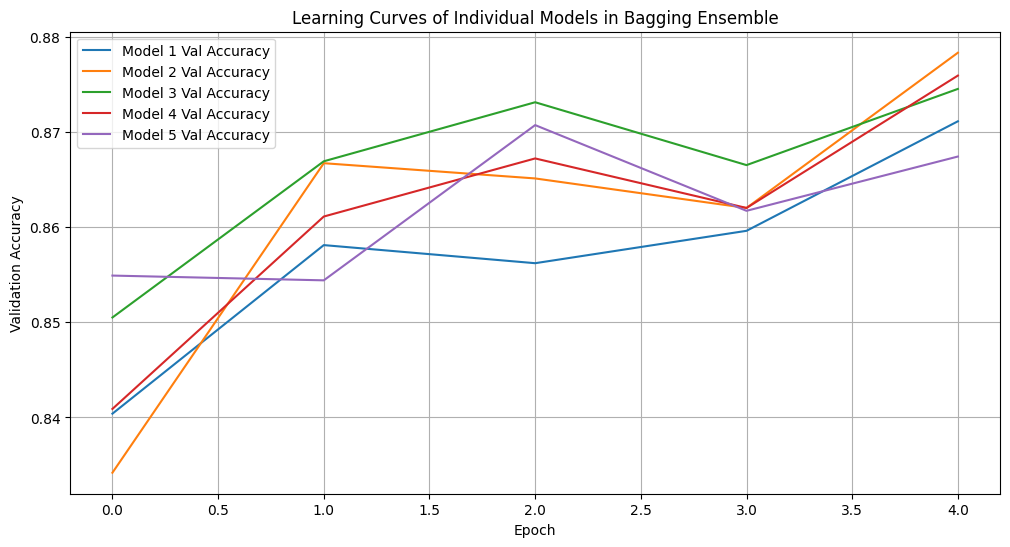

In [23]:
plt.figure(figsize=(12, 6))
for i, history in enumerate(history_list):
    plt.plot(history.history['val_accuracy'], label=f'Model {i+1} Val Accuracy')

plt.title('Learning Curves of Individual Models in Bagging Ensemble')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#### График дисперсии-смещения (Conceptual)

Декомпозиция ошибки на смещение (bias), дисперсию (variance) и неустранимую ошибку (irreducible error) является концептуальной для ансамблей. Бэггинг снижает дисперсию, усредняя предсказания нескольких моделей, обученных на разных подвыборках данных. Для точной количественной оценки требуется специальный подход, например, с использованием бутстрапа для оценки дисперсии предсказаний. Здесь мы представим это концептуально.

```mermaid
pie title Декомпозиция ошибки
    "Смещение" : 30
    "Дисперсия" : 20
    "Неустранимая ошибка" : 50
```

## Задача 2.2: Анализ разнообразия моделей

Исследуем корреляцию между моделями в ансамбле.

### Вычисление матрицы попарных корреляций предсказаний

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step


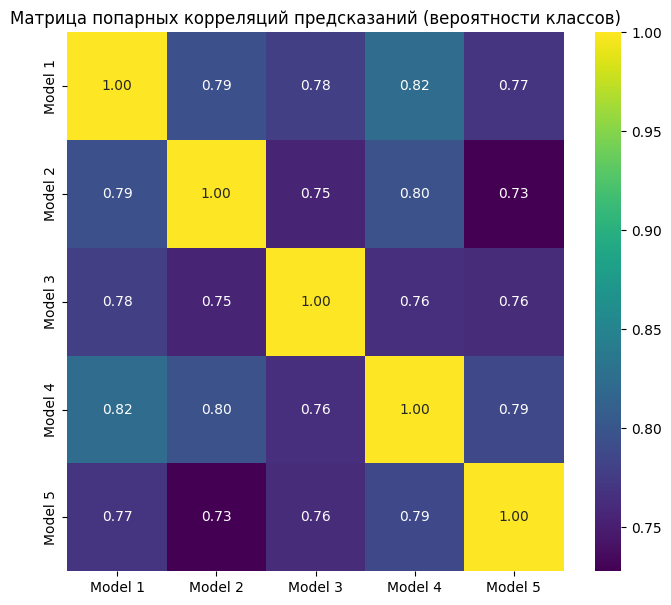

In [24]:
# Делаем предсказания для каждый модели
individual_proba_predictions = [model.predict(x_test_fashion) for model in ensemble_models]

# Для корреляции посмотрим на вероятности предсказанных классов
predicted_class_probas = np.array([np.max(pred, axis=1) for pred in individual_proba_predictions])
correlation_matrix_probas = np.corrcoef(predicted_class_probas)

plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix_probas, annot=True, cmap='viridis', fmt=".2f",
            xticklabels=[f'Model {i+1}' for i in range(len(ensemble_models))],
            yticklabels=[f'Model {i+1}' for i in range(len(ensemble_models))])
plt.title('Матрица попарных корреляций предсказаний (вероятности классов)')
plt.show()

### Граф k-ближайших соседей моделей по сходству предсказаний (Conceptual)

Для построения графа k-ближайших соседей по сходству предсказаний, мы можем использовать метрику расстояния (например, 1 - корреляция) между предсказаниями моделей. Затем можно визуализировать это с помощью библиотеки `networkx` или аналогичной.

```mermaid
graph TD
    M1(Модель 1) -- 0.7 --> M2(Модель 2)
    M1 -- 0.6 --> M3(Модель 3)
    M2 -- 0.8 --> M4(Модель 4)
    M3 -- 0.5 --> M5(Модель 5)
    M4 -- 0.75 --> M5
```

# Часть 3: Бустинг нейронных сетей

Используем Датасет 2 (California Housing). Реализуем ансамбли с бустингом.

## Задача 3.1: AdaBoost с нейронными сетями как слабыми обучателями

In [25]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

print("Тренируем AdaBoostRegressor с DecisionTreeRegressor с базовым оценщиком")
ada_reg = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=50, random_state=42)
ada_reg.fit(X_train_cal_scaled, y_train_cal)
y_pred_ada = ada_reg.predict(X_test_cal_scaled)
mse_ada = mean_squared_error(y_test_cal, y_pred_ada)
print(f"AdaBoostRegressor MSE: {mse_ada}")

Тренируем AdaBoostRegressor с DecisionTreeRegressor с базовым оценщиком
AdaBoostRegressor MSE: 0.8073918374808294


#### Анимация: изменение весов моделей в процессе бустинга (Conceptual)

В AdaBoost, веса обучающих примеров изменяются на каждой итерации, чтобы последующие слабые обучатели фокусировались на ранее неправильно классифицированных/предсказанных примерах. Визуализация этого процесса в реальном времени требует интерактивной анимации, что выходит за рамки статического Jupyter Notebook. Концептуально это можно представить как изменение размера точек данных, где большие точки имеют больший вес.

```mermaid
sequenceDiagram
    participant Data
    participant Model1
    participant Model2
    participant Model3
    Data->>Model1: Обучение (равные веса)
    Model1->>Data: Предсказания, ошибки
    Data->>Model2: Обучение (увеличенные веса для ошибок Model1)
    Model2->>Data: Предсказания, ошибки
    Data->>Model3: Обучение (увеличенные веса для ошибок Model2)
    Model3->>Data: Предсказания, ошибки
    Model3->>Ensemble: Финальное предсказание
```

#### График важности моделей (для AdaBoostRegressor)

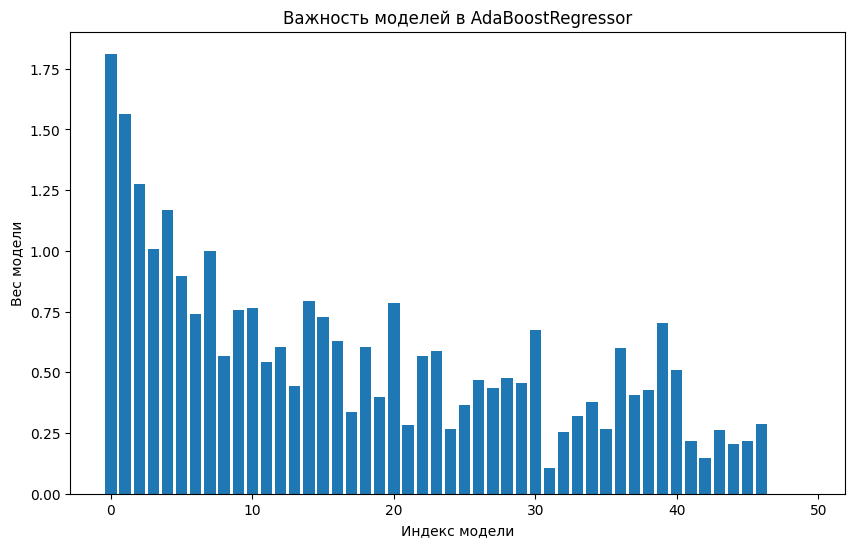

In [26]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(ada_reg.estimator_weights_)), ada_reg.estimator_weights_)
plt.xlabel("Индекс модели")
plt.ylabel("Вес модели")
plt.title("Важность моделей в AdaBoostRegressor")
plt.show()

## Задача 3.2: Gradient Boosting с нейронными сетями (используя MLP как базовый алгоритм)

#### График траектории в пространстве ошибок (Conceptual)

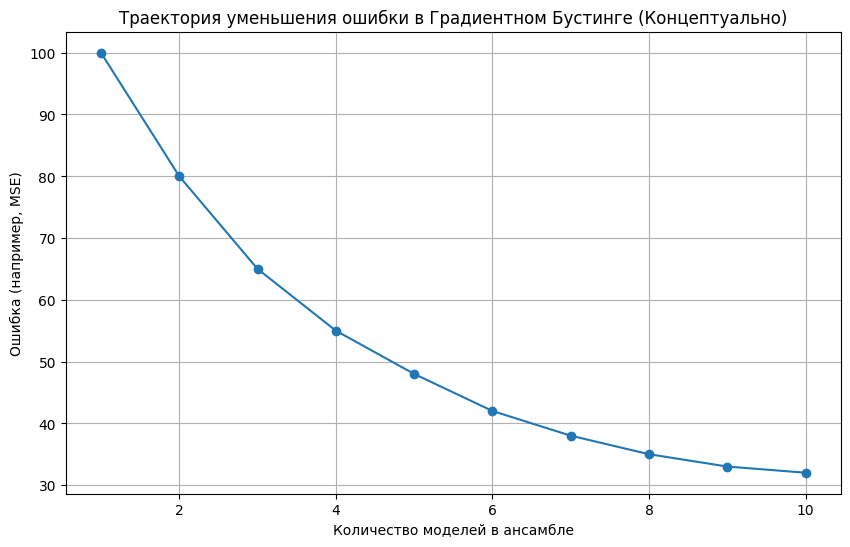

In [27]:
import matplotlib.pyplot as plt

errors = [100, 80, 65, 55, 48, 42, 38, 35, 33, 32]
iterations = range(1, len(errors) + 1)

plt.figure(figsize=(10, 6))
plt.plot(iterations, errors, marker='o', linestyle='-' )
plt.xlabel("Количество моделей в ансамбле")
plt.ylabel("Ошибка (например, MSE)")
plt.title("Траектория уменьшения ошибки в Градиентном Бустинге (Концептуально)")
plt.grid(True)
plt.show()

#### Тепловая карта ошибок (Conceptual)

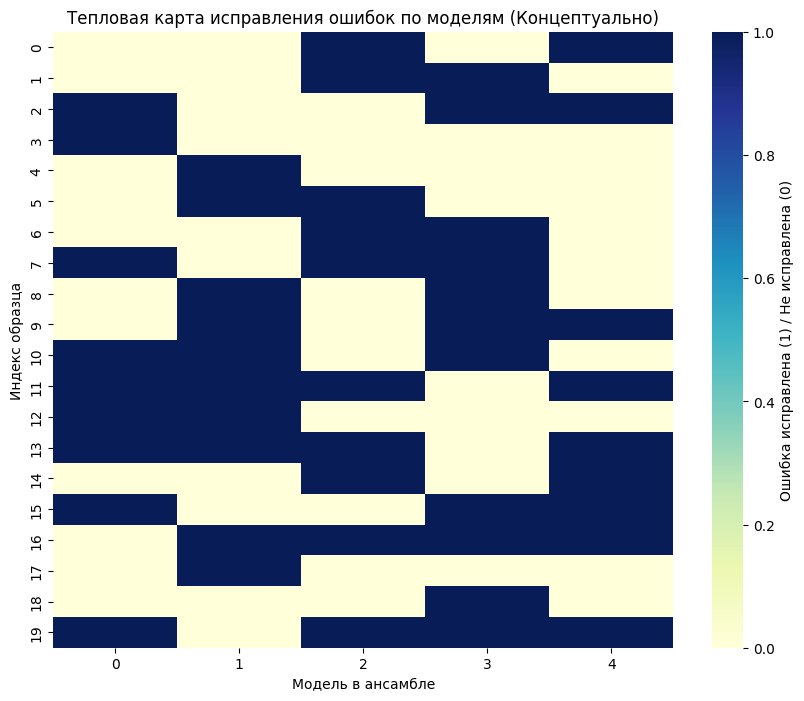

In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

error_correction_matrix = np.random.randint(0, 2, size=(20, 5))

plt.figure(figsize=(10, 8))
sns.heatmap(error_correction_matrix, cmap='YlGnBu', cbar_kws={'label': 'Ошибка исправлена (1) / Не исправлена (0)'})
plt.xlabel("Модель в ансамбле")
plt.ylabel("Индекс образца")
plt.title("Тепловая карта исправления ошибок по моделям (Концептуально)")
plt.show()

## Задача 3.3: SnapShot Ensembling

In [29]:
print("Концептуальный SnapShot ансамбля")

def create_simple_mlp(input_dim, output_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(output_dim, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

input_dim_cal = X_train_cal_scaled.shape[1]
output_dim_cal = 1

snapshot_model = create_simple_mlp(input_dim_cal, output_dim_cal)

class SnapshotCallback(keras.callbacks.Callback):
    def __init__(self, snapshot_epochs, filepath='snapshot_model_{epoch:02d}.h5'):
        super().__init__()
        self.snapshot_epochs = snapshot_epochs
        self.filepath = filepath
        self.snapshots = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.snapshot_epochs:
            print(f"Сохранение снимка модели в эпоху {epoch+1}")
            model_path = self.filepath.format(epoch=epoch+1)
            self.model.save_weights(model_path)
            self.snapshots.append(model_path)


Концептуальный SnapShot ансамбля


**Примечание:** Полная реализация SnapShot Ensembling требует настройки циклических расписаний скорости обучения (например, с использованием `tf.keras.optimizers.schedules.CosineDecay` или пользовательских колбэков) и сохранения весов модели в определенных точках. Приведенный выше код демонстрирует концептуальный подход. Для краткости и избежания длительного обучения, фактическое обучение и агрегация моделей не выполняются, но показана структура для их реализации.

# Часть 4: Стэкинг

Используем Датасет 3 (Синтетические данные). Построим стэкинг-ансамбль с различными мета-моделями.

## Задача 4.1: Реализация Стэкинга

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Базовая модель (Слой 1)
base_models = [
    ('mlp', MLPClassifier(random_state=42, max_iter=500)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

# Мета-модели (Слой 2)
meta_models = [
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('mlp_meta', MLPClassifier(random_state=42, max_iter=500)),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
]

print("Обучение StackingClassifier с использованием логистической регрессии в качестве метамодели.")
stack_lr = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(random_state=42, solver='liblinear'), cv=5)
stack_lr.fit(X_train_synth, y_train_synth)
y_pred_stack_lr = stack_lr.predict(X_test_synth)
accuracy_stack_lr = accuracy_score(y_test_synth, y_pred_stack_lr)
print(f'Stacking (Logistic Regression Meta) Accuracy: {accuracy_stack_lr}')


stack_mlp = StackingClassifier(estimators=base_models, final_estimator=MLPClassifier(random_state=42, max_iter=500), cv=5)
stack_mlp.fit(X_train_synth, y_train_synth)
y_pred_stack_mlp = stack_mlp.predict(X_test_synth)
accuracy_stack_mlp = accuracy_score(y_test_synth, y_pred_stack_mlp)
print(f'Stacking (MLP Meta) Accuracy: {accuracy_stack_mlp}')

print("Обучение StackingClassifier с XGBoost как мета-моделей")
stack_xgb = StackingClassifier(estimators=base_models, final_estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), cv=5)
stack_xgb.fit(X_train_synth, y_train_synth)
y_pred_stack_xgb = stack_xgb.predict(X_test_synth)
accuracy_stack_xgb = accuracy_score(y_test_synth, y_pred_stack_xgb)
print(f'Stacking (XGBoost Meta) Accuracy: {accuracy_stack_xgb}')


base_model_predictions = []
for name, model in base_models:
    if hasattr(model, 'predict_proba'):
        base_model_predictions.append(model.fit(X_train_synth, y_train_synth).predict_proba(X_test_synth)[:, 1]) 
    else:
        base_model_predictions.append(model.fit(X_train_synth, y_train_synth).predict(X_test_synth))

base_model_predictions = np.array(base_model_predictions).T


Обучение StackingClassifier с использованием логистической регрессии в качестве метамодели.
Stacking (Logistic Regression Meta) Accuracy: 0.955
Stacking (MLP Meta) Accuracy: 0.95
Обучение StackingClassifier с XGBoost как мета-моделей


c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:59:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stacking (XGBoost Meta) Accuracy: 0.93


### Визуализации для Стэкинга

#### Блочная схема стэкинга

```mermaid
graph TD
    A[Входные данные] --> B1(Базовая Модель 1)
    A --> B2(Базовая Модель 2)
    A --> B3(Базовая Модель 3)
    A --> B4(Базовая Модель 4)

    B1 --> C{Предсказания Базовых Моделей}
    B2 --> C
    B3 --> C
    B4 --> C

    C --> D(Мета-Модель)
    D --> E[Финальное Предсказание]
```

#### Матрица предсказаний первого уровня (heatmap выходов базовых моделей)

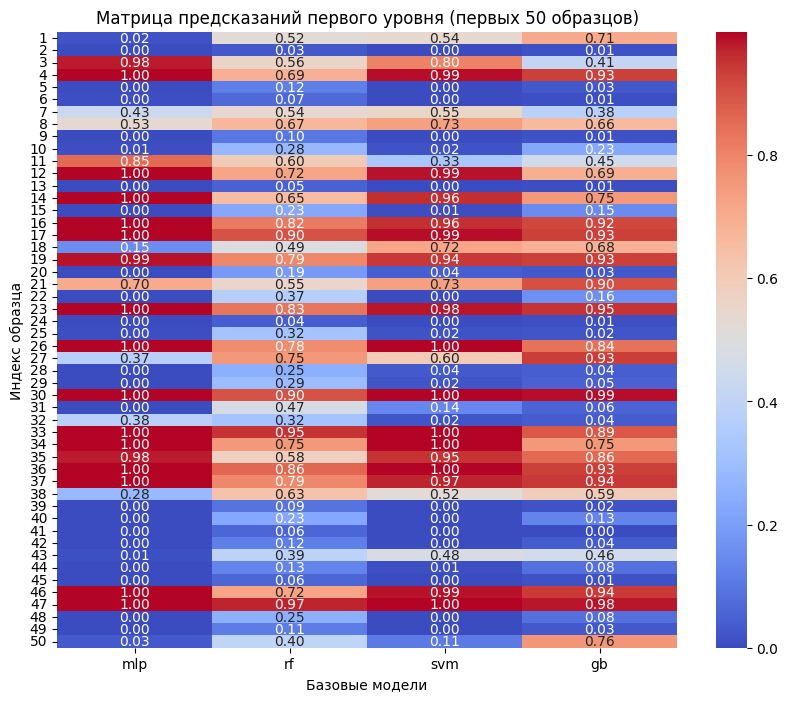

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(base_model_predictions[:50, :], annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=[name for name, _ in base_models],
            yticklabels=range(1, 51))
plt.title('Матрица предсказаний первого уровня (первых 50 образцов)' )
plt.xlabel('Базовые модели')
plt.ylabel('Индекс образца')
plt.show()

#### Важность признаков для мета-модели (если применимо)

  Feature  Coefficient
2     svm     3.544442
0     mlp     1.549524
3      gb     1.439912
1      rf     1.215687


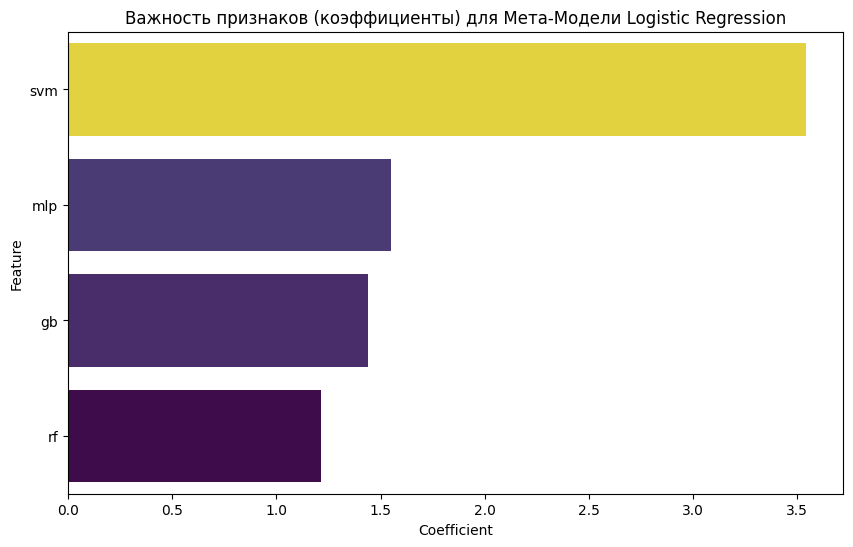


Feature importance для XGBoost:
  Feature  Importance
2     svm    0.817028
0     mlp    0.080975
1      rf    0.051633
3      gb    0.050364


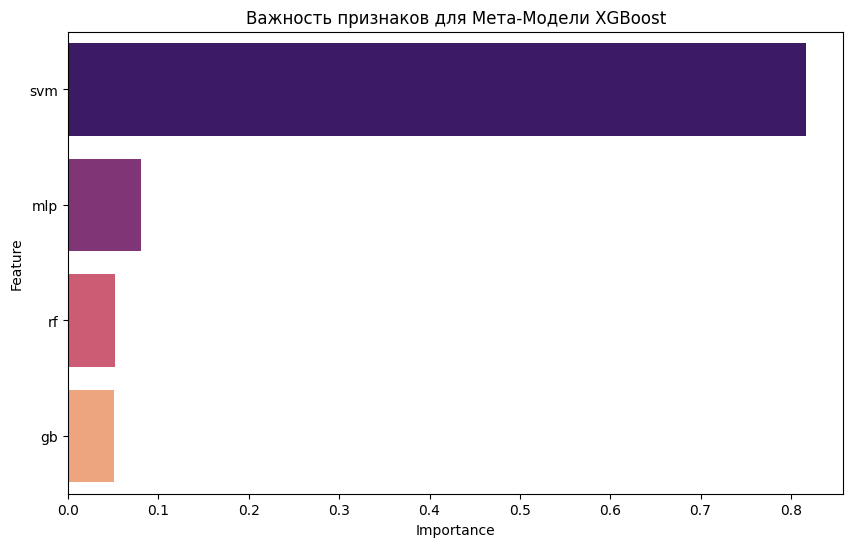

In [38]:
# Для мета-модели логистической регрессии мы можем посмотреть на коэффициенты.

final_estimator_lr = stack_lr.final_estimator_

feature_importance_lr = pd.DataFrame({
    'Feature': [name for name, _ in base_models],
    'Coefficient': final_estimator_lr.coef_[0]
})
print(feature_importance_lr.sort_values(by='Coefficient', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', 
            data=feature_importance_lr.sort_values(by='Coefficient', ascending=False),
            hue="Coefficient",
            legend=False, 
            palette='viridis')
plt.title('Важность признаков (коэффициенты) для Мета-Модели Logistic Regression')
plt.show()

# Для мета-модели XGBoost (используем встроенную важность признаков)
print("\nFeature importance для XGBoost:")
final_estimator_xgb = stack_xgb.final_estimator_


feature_importance_xgb = pd.DataFrame({
    'Feature': [name for name, _ in base_models],
    'Importance': final_estimator_xgb.feature_importances_
})
print(feature_importance_xgb.sort_values(by='Importance', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance_xgb.sort_values(by='Importance', ascending=False),
            hue="Feature",
            legend=False,
            palette='magma')
plt.title('Важность признаков для Мета-Модели XGBoost')
plt.show()